In [24]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
truck_df = pd.read_excel("./data/Delivery truck trip data.xlsx")
truck_df.head()

,GpsProvider,BookingID,Market/Regular,BookingID_Date,vehicle_no,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,...,TRANSPORTATION_DISTANCE_IN_KM,vehicleType,Minimum_kms_to_be_covered_in_a_day,Driver_Name,Driver_MobileNo,customerID,customerNameCode,supplierID,supplierNameCode,Material Shipped
0,CONSENT TRACK,MVCV0000927/082021,Market,2020-08-17 14:59:01.000,KA590408,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",2020-08-24 00:05:09,...,320.0,NaN,NaN,NaN,NaN,ALLEXCHE45,Ashok leyland limited,VIJEXHOSR7,VIJAY TRANSPORT,BRACKET / GRAB HANDLE
1,VAMOSYS,VCV00014271/082021,Regular,2020-08-27 16:22:22.827,TN30BC5917,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:28,...,103.0,NaN,NaN,RAMESH,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,VJLEXSHE09,VJ LOGISTICS,ZB MODEL PLATE / 3143
2,CONSENT TRACK,VCV00014382/082021,Regular,2020-08-27 17:59:24.987,TN22AR2748,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",2020-08-28 09:05:09,...,300.0,NaN,NaN,GIRI,NaN,LUTGCCHE06,Lucas tvs ltd,GSTEXLAK1Q,G.S. TRANSPORT,LETTERING / FUSO
3,VAMOSYS,VCV00014743/082021,Regular,2020-08-28 00:48:24.503,TN28AQ0781,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:31,...,61.0,NaN,NaN,RAVI,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,ARVEXNAM09,ARVINTH TRANSPORT,LU STRUT RA / RADIUS ROD
4,VAMOSYS,VCV00014744/082021,Regular,2020-08-28 01:23:19.243,TN68F1722,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",2020-08-28 12:40:29,...,240.0,NaN,NaN,TAMIL,NaN,LUTGCCHE06,Lucas tvs ltd,SRTEXKOR96,SR TRANSPORTS,WISHBONE / V ROD/HDT


LASSO

In [3]:
# prompt: get only numr

truck_df.describe


<bound method NDFrame.describe of         GpsProvider           BookingID Market/Regular   \
0     CONSENT TRACK  MVCV0000927/082021          Market   
1           VAMOSYS  VCV00014271/082021         Regular   
2     CONSENT TRACK  VCV00014382/082021         Regular   
3           VAMOSYS  VCV00014743/082021         Regular   
4           VAMOSYS  VCV00014744/082021         Regular   
...             ...                 ...             ...   
6875          JTECH        WDSBKTP42751         Regular   
6876          JTECH        WDSBKTP43203         Regular   
6877          JTECH        WDSBKTP43021         Regular   
6878          JTECH        WDSBKTP42685         Regular   
6879          JTECH        WDSBKTP42858         Regular   

              BookingID_Date  vehicle_no  \
0    2020-08-17 14:59:01.000    KA590408   
1    2020-08-27 16:22:22.827  TN30BC5917   
2    2020-08-27 17:59:24.987  TN22AR2748   
3    2020-08-28 00:48:24.503  TN28AQ0781   
4    2020-08-28 01:23:19.243   TN68F1

In [4]:
truck_df['GpsProvider'].value_counts()

GpsProvider
CONSENT TRACK             3859
VAMOSYS                    788
EKTA                       322
JTECH                      241
MANUAL                     219
KRC LOGISTICS              175
WDSL                        72
BEECON                      34
NUEVASTECH                  29
Garuda                      28
APACE_TRANSCO               22
SAILOGISTICS                21
FLEETX                      19
VIRSTEMPO                   14
BALLY LOGISTICS             13
TRANS CARGO INDIA           10
PRATHIKSHATRANSPORT          8
Sri Vinayaka Transport       8
NIMBLE                       7
SahilCargo                   7
WABCOTRANS                   6
TransCargo                   5
Cargo Carriers               5
VINAYAKA_TVS                 5
BHIWADIDELHIROADLINE         4
DHILLONGOODS                 2
PREM TRANSPORT               2
FORIGOTRANS                  1
INSTANT                      1
Name: count, dtype: int64

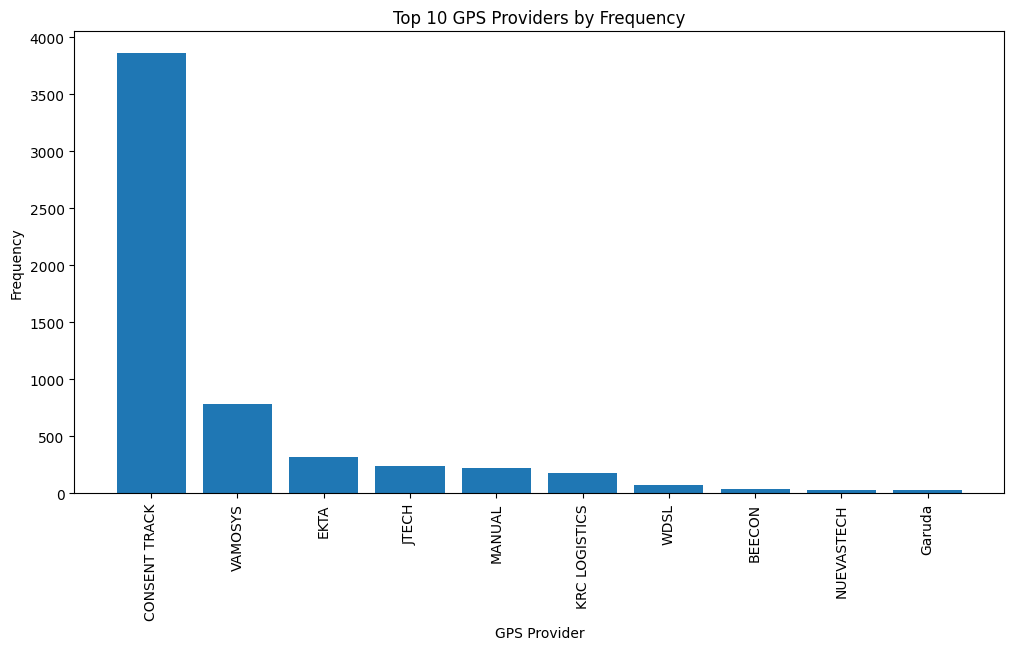

In [5]:
gps_provider_counts = truck_df['GpsProvider'].value_counts()
top_10_gps_providers = gps_provider_counts[:10]

plt.figure(figsize=(12, 6))
plt.bar(top_10_gps_providers.index, top_10_gps_providers.values)
plt.xlabel('GPS Provider')
plt.ylabel('Frequency')
plt.title('Top 10 GPS Providers by Frequency')
plt.xticks(rotation=90)  # Rotate x labels if they overlap
plt.show()

In [6]:
    # # Convert datetime columns
    # truck_df["Planned_ETA"] = pd.to_datetime(truck_df["Planned_ETA"])
    # truck_df["actual_eta"] = pd.to_datetime(truck_df["actual_eta"])

    # # Compute delay (target variable)
    # truck_df["delay"] = (truck_df["actual_eta"] - truck_df["Planned_ETA"]).dt.total_seconds() / 3600  # Convert to hours

    # # Split latitude and longitude into separate columns
    # truck_df[['Org_lat', 'Org_lon']] = truck_df['Org_lat_lon'].str.split(',', expand=True).astype(float)
    # truck_df[['Des_lat', 'Des_lon']] = truck_df['Des_lat_lon'].str.split(',', expand=True).astype(float)

    # # Select numeric and categorical features
    # features = ["Org_lat", "Org_lon", "Des_lat", "wDes_lon"]

    # # Ensure the column name is correct
    # if "Market/Regular" in truck_df.columns:
    #     truck_df = pd.get_dummies(truck_df, columns=["GpsProvider", "Market/Regular"], drop_first=True)  # One-hot encoding
    # else:
    #     truck_df = pd.get_dummies(truck_df, columns=["GpsProvider"], drop_first=True)  # One-hot encoding

    # # Extract feature matrix and target
    # X = truck_df[features]
    # y = truck_df["delay"].fillna(0)  # Fill NaN values in delay

    # # Train-test split
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # # Standardize features
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test = scaler.transform(X_test)

    # # Apply LASSO regression
    # lasso = Lasso(alpha=0.1)  # Alpha controls regularization strength
    # lasso.fit(X_train, y_train)

    # # Predictions and evaluation
    # y_pred = lasso.predict(X_test)
    # mae = mean_absolute_error(y_test, y_pred)
    # print(f"Mean Absolute Error: {mae}")

    # # Identify important features
    # important_features = pd.Series(lasso.coef_, index=features)
    # print("Important Features:")
    # print(important_features)

STEP-WISE LINEAR REGRESSION

In [7]:
# import statsmodels.api as sm

# # Add a constant to the features
# X_train_const = sm.add_constant(X_train)
# X_test_const = sm.add_constant(X_test)

# # Fit the initial model with all features
# initial_model = sm.OLS(y_train, X_train_const).fit()

# # Perform stepwise regression
# def stepwise_selection(X, y, 
# 					   initial_list=[], 
# 					   threshold_in=0.01, 
# 					   threshold_out=0.05, 
# 					   verbose=True):
# 	included = list(initial_list)
# 	while True:
# 		changed = False
# 		# forward step
# 		excluded = list(set(X.columns) - set(included))
# 		new_pval = pd.Series(index=excluded)
# 		for new_column in excluded:
# 			model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
# 			new_pval[new_column] = model.pvalues[new_column]
# 		best_pval = new_pval.min()
# 		if best_pval < threshold_in:
# 			best_feature = new_pval.idxmin()
# 			included.append(best_feature)
# 			changed = True
# 			if verbose:
# 				print(f'Add  {best_feature:30} with p-value {best_pval:.6}')

# 		# backward step
# 		model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
# 		# use all coefs except the constant
# 		pvalues = model.pvalues.iloc[1:]
# 		worst_pval = pvalues.max()
# 		if worst_pval > threshold_out:
# 			changed = True
# 			worst_feature = pvalues.idxmax()
# 			included.remove(worst_feature)
# 			if verbose:
# 				print(f'Drop {worst_feature:30} with p-value {worst_pval:.6}')
# 		if not changed:
# 			break
# 	return included

# result = stepwise_selection(pd.DataFrame(X_train, columns=features), y_train)

# # Fit the final model with selected features
# final_model = sm.OLS(y_train, sm.add_constant(pd.DataFrame(X_train, columns=result))).fit()
# print(final_model.summary())

# # Predict and evaluate
# y_pred_stepwise = final_model.predict(sm.add_constant(pd.DataFrame(X_test, columns=result)))
# mae_stepwise = mean_absolute_error(y_test, y_pred_stepwise)
# print(f"Mean Absolute Error (Stepwise): {mae_stepwise}")

CORRELATION COEFFICIENT ANALYSIS

1. kilometers to destination states
2. top states driven to
3. GDP of states driven to
4. correlation between GDP, miles driven, delay factor and number of trips.
4. predict GDP based on miles driven, delay factor, number of trips

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import tabulate


In [9]:

# Load dataset
orig_df = pd.read_excel("./data/Delivery truck trip data.xlsx")
orig_df.columns


Index(['GpsProvider', 'BookingID', 'Market/Regular ', 'BookingID_Date',
       'vehicle_no', 'Origin_Location', 'Destination_Location', 'Org_lat_lon',
       'Des_lat_lon', 'Data_Ping_time', 'Planned_ETA', 'Current_Location',
       'DestinationLocation', 'actual_eta', 'Curr_lat', 'Curr_lon', 'ontime',
       'delay', 'OriginLocation_Code', 'DestinationLocation_Code',
       'trip_start_date', 'trip_end_date', 'TRANSPORTATION_DISTANCE_IN_KM',
       'vehicleType', 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name',
       'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID',
       'supplierNameCode', 'Material Shipped'],
      dtype='object')

In [10]:
drop_columns = ['vehicle_no', 'Data_Ping_time', 'BookingID', 'BookingID_Date', 'DestinationLocation_Code',  'OriginLocation_Code',
		 'Minimum_kms_to_be_covered_in_a_day', 'Driver_Name', 'Driver_MobileNo', 'customerID', 'customerNameCode', 'supplierID',
		 'supplierNameCode', 'Material Shipped','vehicleType']
# Drop columns if they exist
orig_df.drop(columns=[col for col in drop_columns if col in orig_df.columns], inplace=True)

In [11]:

# Convert datetime columns
orig_df["Planned_ETA"] = pd.to_datetime(orig_df["Planned_ETA"])
orig_df["actual_eta"] = pd.to_datetime(orig_df["actual_eta"])

# Compute delay in hours
orig_df["delay"] = (orig_df["actual_eta"] - orig_df["Planned_ETA"]).dt.total_seconds() / 3600

# Extract state information if needed (assuming states are part of destination location)
orig_df["Destination_State"] = orig_df["Destination_Location"].str.split(",").str[-1].str.strip()


In [12]:
# Calculating the distance between two points
# Assuming 'Org_lat_lon' and 'Des_lat_lon' contain (latitude, longitude) pairs
from geopy.distance import geodesic

def calculate_distance(row):
    try:
        origin = tuple(map(float, row["Org_lat_lon"].split(",")))
        destination = tuple(map(float, row["Des_lat_lon"].split(",")))
        return geodesic(origin, destination).km
    except:
        return np.nan  # Handle missing data

orig_df["distance_km"] = orig_df.apply(calculate_distance, axis=1)


/tmp/ipykernel_1883398/1632484594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette="Blues_d")


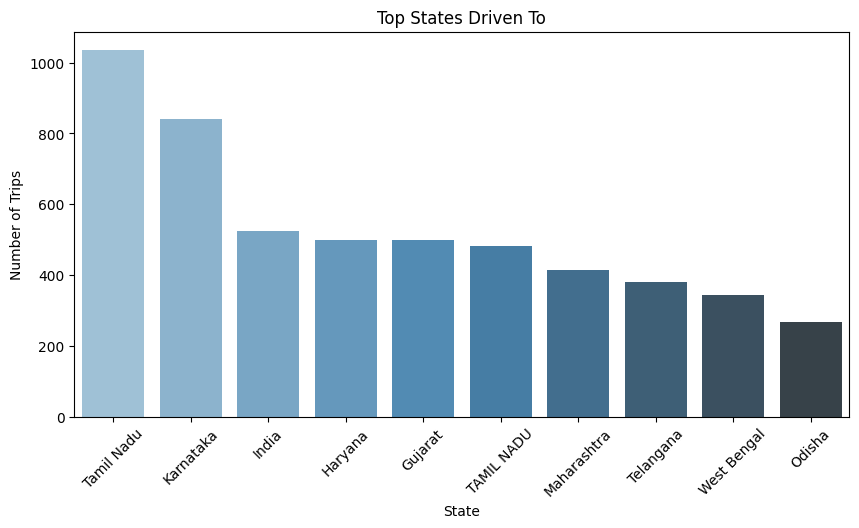

In [13]:
#Graph showing the top 10 states driven to
top_states = orig_df["Destination_State"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.index, y=top_states.values, palette="Blues_d")
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Number of Trips")
plt.title("Top States Driven To")
plt.show()


In [14]:
#Get GDP data for each state
gdp_data = pd.read_csv("./data/Indias GDP (Statewise).csv")  # File should contain "State" and "GDP" columns
#remove index column
gdp_data = gdp_data.iloc[:, 1:]
# drop column of gdp in rupees
gdp_data.drop('Nominal GDP(Trillion INR)', axis=1, inplace=True)
# Rename columns for consistency
gdp_data.rename(columns={"State_UT": "State", "Nominal GDP(Trillion USD)": "GDP"}, inplace=True)
top_ten_states = gdp_data.head(10)
print(f"The top 10 states by GDP are:\n{top_ten_states.to_markdown(index=False)}")

The top 10 states by GDP are:
| State          |   Nominal GDP(Billion USD) |
|:---------------|---------------------------:|
| Maharashtra    |                        450 |
| Tamil Nadu     |                        290 |
| Gujarat        |                        260 |
| Karnataka      |                        250 |
| Uttar Pradesh  |                        250 |
| West Bengal    |                        210 |
| Rajasthan      |                        160 |
| Telangana      |                        160 |
| Andhra Pradesh |                        150 |
| Madhya pradesh |                        140 |


In [15]:
top_ten_states.columns

Index(['State', 'Nominal GDP(Billion USD)'], dtype='object')

/tmp/ipykernel_1883398/2317744167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ten_states["State"], y=top_ten_states["Nominal GDP(Billion USD)"], palette="Reds_d")


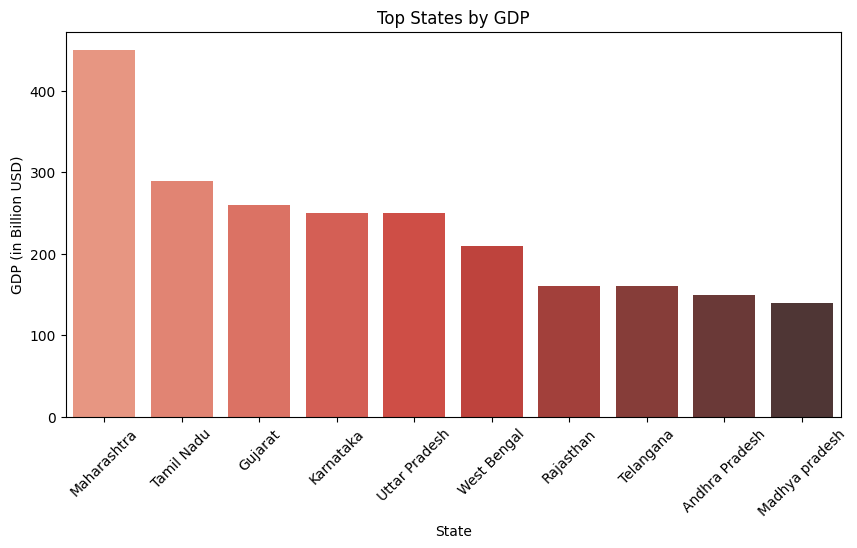

In [16]:
#states with the highest GDP
plt.figure(figsize=(10, 5))
sns.barplot(x=top_ten_states["State"], y=top_ten_states["Nominal GDP(Billion USD)"], palette="Reds_d")
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("GDP (in Billion USD)")
plt.title("Top States by GDP")
plt.show()

In [17]:
orig_df["Destination_State"] = orig_df["Destination_State"].str.title()
orig_df["Destination_State"] = orig_df["Destination_State"].replace("Pondicherry", "Puducherry")

In [18]:
merged_df = orig_df.merge(gdp_data, left_on="Destination_State", right_on="State", how="left")
# df.drop(columns=["State"], inplace=True)  # Remove duplicate column
merged_df

,GpsProvider,Market/Regular,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Planned_ETA,Current_Location,DestinationLocation,actual_eta,...,Curr_lon,ontime,delay,trip_start_date,trip_end_date,TRANSPORTATION_DISTANCE_IN_KM,Destination_State,distance_km,State,Nominal GDP(Billion USD)
0,CONSENT TRACK,Market,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",2020-08-21 18:59:01.000,"Vaniyambadi Rd, Valayambattu, Tamil Nadu 63575...","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA",2020-08-28 14:38:04.447,...,78.649870,NaN,163.650958,2020-08-17 14:59:01,NaN,320.0,Karnataka,261.868350,Karnataka,250.0
1,VAMOSYS,Regular,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-31 20:22:22.827,"Unnamed Road, Oragadam Industrial Corridor, Va...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-28 12:46:17.007,...,79.954428,G,-79.601617,2020-08-27 16:21:52,NaN,103.0,Tamil Nadu,0.000000,Tamil Nadu,290.0
2,CONSENT TRACK,Regular,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",2020-08-31 21:59:24.987,"570, National Hwy 48, Shenoy Nagar, Chennai, T...","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-28 16:03:30.793,...,80.225780,G,-77.931721,2020-08-27 17:57:04,NaN,300.0,Puducherry,0.000000,Puducherry,5.0
3,VAMOSYS,Regular,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-09-01 04:48:24.503,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...",2020-08-28 12:50:27.997,...,79.950560,G,-87.965696,2020-08-28 00:47:45,NaN,61.0,Tamil Nadu,0.000000,Tamil Nadu,290.0
4,VAMOSYS,Regular,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",2020-09-01 05:23:19.243,"Melmaruvathur, Tamil Nadu 603319, India","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY",2020-08-28 14:22:50.127,...,79.831556,G,-87.008088,2020-08-28 01:13:48,NaN,240.0,Puducherry,0.000000,Puducherry,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6875,JTECH,Regular,"Ramamurthy Nagar, Bangalore, Karnataka","Sahakaranagar P.O, Bangalore, Karnataka","13.007503209603689,77.665098855934886","13.068901840235711,77.590655738806618",2019-03-27 18:31:00.000,"SGT Goods Shed Rd, Kadugodi, Bengaluru, Karnat...","Sahakaranagar P.O, Bangalore, Karnataka",2019-03-27 17:46:00.000,...,77.740616,G,-0.750000,2019-03-27 18:00:00,2019-03-27 17:46:00,12.0,Karnataka,10.551778,Karnataka,250.0
6876,JTECH,Regular,"Ramamurthy Nagar, Bangalore, Karnataka","Bangalore International Airport, Bangalore, Ka...","13.007503209603689,77.665098855934886","13.196312912801169,77.708156925688726",2019-03-31 20:36:00.000,"Shed No 60, Medahalli Kadugodi Road, Virgonaga...","Bangalore International Airport, Bangalore, Ka...",2019-03-31 19:51:00.000,...,77.722391,G,-0.750000,2019-03-31 17:30:00,2019-03-31 19:51:00,31.0,Karnataka,21.403777,Karnataka,250.0
6877,JTECH,Regular,"Mugabala, Bangalore Rural, Karnataka","Anekal, Bangalore, Karnataka","16.560192249175344,80.792293091599547","12.722686,77.676518",2019-03-30 01:38:00.000,"Shed No 60, Medahalli Kadugodi Road, Virgonaga...","Anekal, Bangalore, Karnataka",2019-03-30 00:53:00.000,...,77.722391,G,-0.750000,2019-03-29 20:44:00,2019-03-30 00:53:00,49.0,Karnataka,541.202265,Karnataka,250.0
6878,JTECH,Regular,"Mugabala, Bangalore Rural, Karnataka","Anekal, Bangalore, Karnataka","16.560192249175344,80.792293091599547","12.896896847817695,77.712223056874862",2019-03-27 17:20:00.000,"Shed No 60, Medahalli Kadugodi Road, Virgonaga...","Anekal, Bangalore, Karnataka",2019-03-27 16:35:00.000,...,77.721823,NaN,-0.750000,2019-03-27 15:29:00,2019-03-27 16:35:00,49.0,Karnataka,523.694406,Karnataka,250.0


In [19]:
correlation_df = merged_df.copy()

# Drop columns that do not have a numeric data type
columns_to_drop = correlation_df.select_dtypes(exclude=np.number).columns
correlation_df.drop(columns=columns_to_drop, inplace=True, errors="ignore")

correlation_df

,Curr_lat,Curr_lon,delay,TRANSPORTATION_DISTANCE_IN_KM,distance_km,Nominal GDP(Billion USD)
0,12.663500,78.649870,163.650958,320.0,261.868350,250.0
1,12.836757,79.954428,-79.601617,103.0,0.000000,290.0
2,13.073956,80.225780,-77.931721,300.0,0.000000,5.0
3,12.836686,79.950560,-87.965696,61.0,0.000000,290.0
4,12.429501,79.831556,-87.008088,240.0,0.000000,5.0
...,...,...,...,...,...,...
6875,12.996370,77.740616,-0.750000,12.0,10.551778,250.0
6876,13.024788,77.722391,-0.750000,31.0,21.403777,250.0
6877,13.024788,77.722391,-0.750000,49.0,541.202265,250.0
6878,13.024747,77.721823,-0.750000,49.0,523.694406,250.0


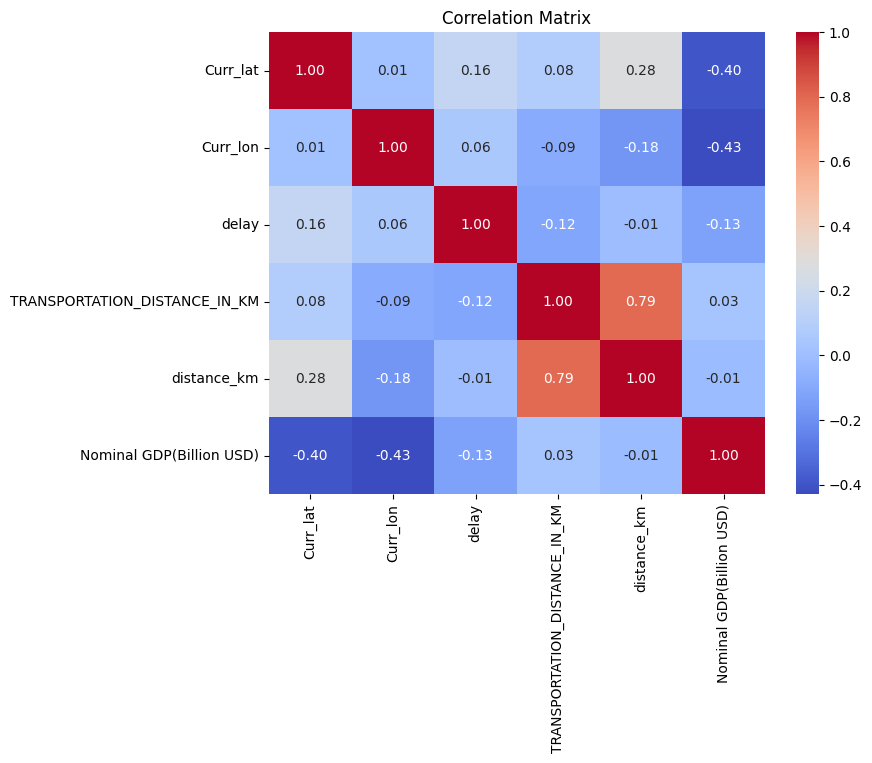

In [20]:
# Correlation matrix
# Compute correlation matrix
corr_matrix = correlation_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [21]:
merged_df.columns

Index(['GpsProvider', 'Market/Regular ', 'Origin_Location',
       'Destination_Location', 'Org_lat_lon', 'Des_lat_lon', 'Planned_ETA',
       'Current_Location', 'DestinationLocation', 'actual_eta', 'Curr_lat',
       'Curr_lon', 'ontime', 'delay', 'trip_start_date', 'trip_end_date',
       'TRANSPORTATION_DISTANCE_IN_KM', 'Destination_State', 'distance_km',
       'State', 'Nominal GDP(Billion USD)'],
      dtype='object')

In [22]:
#Feature Engineering
import statsmodels.api as sm
import pandas as pd
from sklearn.datasets import load_diabetes

# Load dataset
data = merged_df.copy()
data = data.dropna()
data = data.select_dtypes(include=[np.number])  # Keep only numeric columns
X = data.drop(columns=["Nominal GDP(Billion USD)"])
y = data["Nominal GDP(Billion USD)"]

# Stepwise function
def stepwise_selection(X, y, initial_features=[], threshold_in=0.05, threshold_out=0.1):
    selected_features = list(initial_features)
    
    while True:
        changed = False

        # Forward step: Add the best feature
        remaining_features = list(set(X.columns) - set(selected_features))
        new_pvals = pd.Series(index=remaining_features)

        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[selected_features + [feature]])).fit()
            new_pvals[feature] = model.pvalues[feature]

        best_pval = new_pvals.min()
        if best_pval < threshold_in:
            best_feature = new_pvals.idxmin()
            selected_features.append(best_feature)
            changed = True
        
        # Backward step: Remove the worst feature
        model = sm.OLS(y, sm.add_constant(X[selected_features])).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude intercept

        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            selected_features.remove(worst_feature)
            changed = True

        if not changed:
            break

    return selected_features

# Run stepwise selection
selected_features = stepwise_selection(X, y)
print("Selected Features:", selected_features)



Selected Features: ['Curr_lon', 'Curr_lat', 'TRANSPORTATION_DISTANCE_IN_KM']


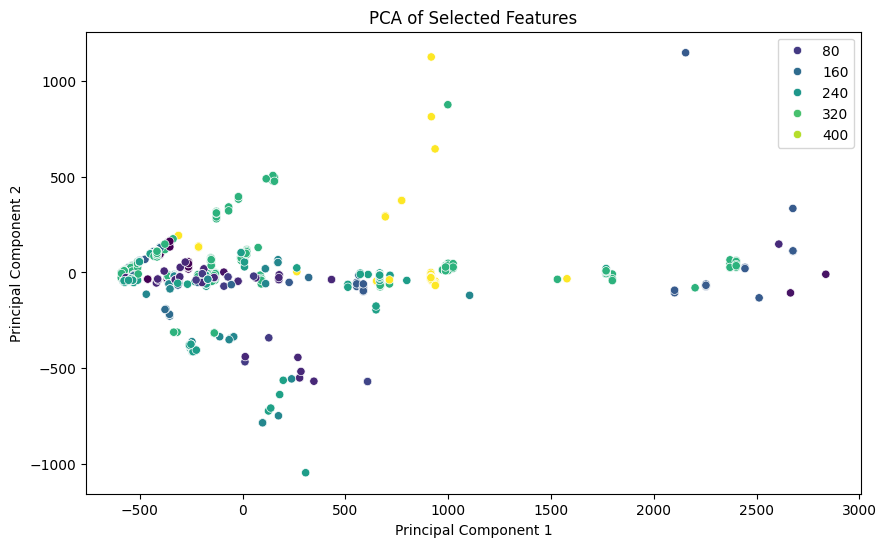

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca_df["Target"] = y.values
plt.figure(figsize=(10, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Target", data=X_pca_df, palette="viridis")
plt.title("PCA of Selected Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [23]:
# Linear Regression
# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


NameError: name 'X_train' is not defined

In [ ]:
#LASSO Regression
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LASSO model
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluation
print("LASSO MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("LASSO R²:", r2_score(y_test, y_pred_lasso))

# Important features
feature_importance = pd.Series(lasso.coef_, index=features)
print("Feature Importance (LASSO):")
print(feature_importance)
